# 02 — Baselines clássicos

Dummy, LogisticRegression, SVM linear e SVM RBF no **mesmo subset** que o QSVM (artefatos do notebook 01).

In [1]:
from pathlib import Path
import sys
import time
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path.cwd().resolve()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
    sys.path.insert(0, str(ROOT / "src"))

from qml_air_quality.config import load_config, project_root
from qml_air_quality.metrics import binary_metrics, metrics_table
from qml_air_quality.models import (
    make_dummy,
    make_linear_svm,
    make_logistic,
    make_rbf_svm,
    predict_proba_positive,
)

ROOT = project_root()
cfg = load_config()
SEED = cfg["project"]["random_seed"]
datasets = ROOT / cfg["paths"]["datasets_dir"]
plots = ROOT / cfg["paths"]["plots_dir"]
plots.mkdir(parents=True, exist_ok=True)

X_train = np.load(datasets / "X_train.npy")
X_val = np.load(datasets / "X_val.npy")
X_test = np.load(datasets / "X_test.npy")
y_train = np.load(datasets / "y_train.npy")
y_val = np.load(datasets / "y_val.npy")
y_test = np.load(datasets / "y_test.npy")
print(X_train.shape, X_test.shape, "pos rate test", y_test.mean())

(500, 4) (200, 4) pos rate test 0.105


In [2]:
models = {
    "dummy": make_dummy(strategy=cfg["classical_models"]["dummy"]["strategy"], seed=SEED),
    "logistic": make_logistic(seed=SEED),
    "svm_linear": make_linear_svm(seed=SEED),
    "svm_rbf": make_rbf_svm(
        seed=SEED,
        C=cfg["classical_models"]["rbf_svm"]["C"],
        gamma=cfg["classical_models"]["rbf_svm"]["gamma"],
    ),
}

rows = []
proba_test = {}
pred_test = {}

for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_s = time.perf_counter() - t0
    t1 = time.perf_counter()
    y_hat = model.predict(X_test)
    y_prob = predict_proba_positive(model, X_test)
    inf_s = time.perf_counter() - t1
    pred_test[name] = y_hat
    proba_test[name] = y_prob
    rows.append(
        binary_metrics(
            y_test,
            y_hat,
            y_prob,
            model_name=name,
            training_seconds=train_s,
            inference_seconds=inf_s,
        )
    )
    print(f"{name}: AUPRC={rows[-1]['average_precision']:.4f} train={train_s:.2f}s")

table = metrics_table(rows)
display(table)
table.to_csv(datasets / "classical_metrics.csv", index=False)

dummy: AUPRC=0.1050 train=0.00s
logistic: AUPRC=0.5330 train=0.00s
svm_linear: AUPRC=0.5328 train=0.03s
svm_rbf: AUPRC=0.3780 train=0.02s


,model,average_precision,balanced_accuracy,precision_extreme,recall_extreme,f1_extreme,mcc,auroc,training_seconds,inference_seconds
0,logistic,0.532967,0.820963,0.361702,0.809524,0.5,0.464116,0.886140,0.002833,0.000241
1,svm_linear,0.532825,0.494413,0.000000,0.000000,0.0,-0.034424,0.899707,0.026682,0.005998
2,svm_rbf,0.378001,0.500000,0.000000,0.000000,0.0,0.000000,0.807396,0.019516,0.010455
3,dummy,0.105000,0.500000,0.000000,0.000000,0.0,0.000000,0.500000,0.004756,0.000297


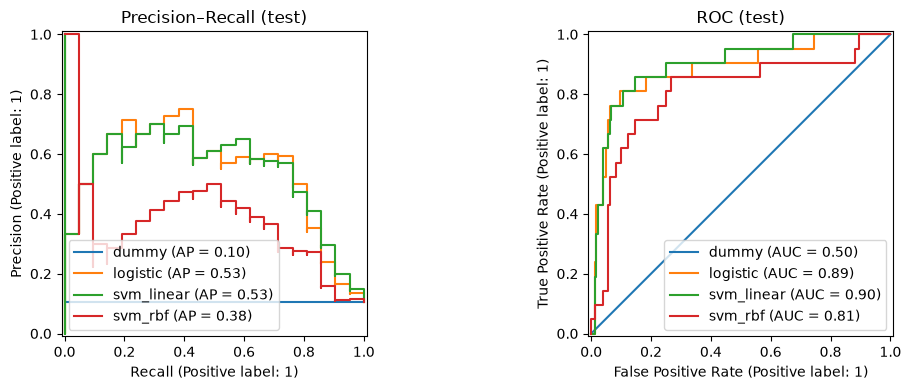

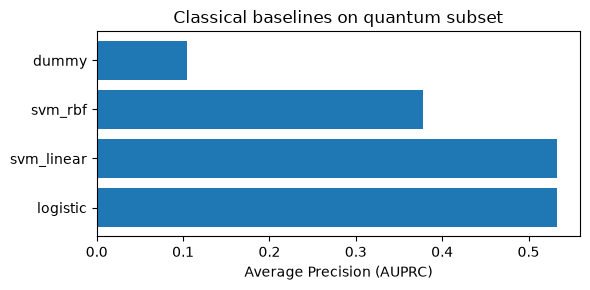

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, y_prob in proba_test.items():
    if y_prob is None:
        continue
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1])
axes[0].set_title("Precision–Recall (test)")
axes[1].set_title("ROC (test)")
fig.tight_layout()
fig.savefig(plots / "classical_pr_roc.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(table["model"], table["average_precision"])
ax.set_xlabel("Average Precision (AUPRC)")
ax.set_title("Classical baselines on quantum subset")
fig.tight_layout()
fig.savefig(plots / "classical_auprc.png", dpi=120)
plt.show()